# Goal:
1. Is the riemannian Hessian hermitian? (real eigenvalues)
2. Can we still apply the gaussian quadrature method to it regardless.
3. What steps need to be changed to be applicable.

# Steps:
1. Verify if hermitian and eigenvalues conditions ✅
2. Evaluate current algorithm on Hermitian matrix to become familiar with the individual steps
    * Copy code from Github repo and bring up to date with current jax implementation
3. Try it out with minimal modifications for Riemannian Hessian and verify eigenspectrum
    * Change to complex case
    * Sample from the right distribution
4. If fails, try with the hermitian version of rH, i.e. (rH + rH^\dagger)/2
    * Is the result somewhat close enough?
5. If fails, make major modifications:
    * Change the way we compute the weights and nodes to work with non-hermitian matrices.
6. Understand if the real spectrum is an accident or something I can exploit.

# Question to ask ChatGPT:

1.  Given a metric for the tangent space of a manifold. How do I sample vectors uniformly distributed in this space? For instance, for the tangent space of the Stiefel Manifold.
2. How can I calculate the Gaussian quadrature weights and nodes in the case where my matrix is a complex non-hermitian matrix.


# Notes from discussion with Raphael:
1. What makes a matrix have real values? Our matrix is not hermitian or normal, so what kind of structure is it?
2. The eigenvalue distribution of the $\mathrm{Herm}(H)$ is different than the eigenvalue distribution of $H$.
3. IDEA 💡: (Hypothesis) we don't really care about the exact number of degrees of freedom from our cost function, but rather that it has converged with respect to the number of sequences. If the conversion from Euclidean -> Stiefel fixes a `constant` number of parameters (constant independent on the number of sequences), then we only care about evaluating the spectrum of the euclidean Hessian and see the convergence with number of sequences ⁉️
    * Test this hypothesis: compute the Riemannian and Euclidean Hessian spectral density (around zero) for different number of sequences to verify our hypothesis
    * If this turns out to be true, back it up with an analytical relation.
    * Then we can simply use the relation for the euclidean Hessian with the Lanczos algorithm and Gaussian Quadrature on complex matrices - since the Euclidean Hessian is hermitian.

# Imports

In [125]:
%load_ext autoreload
%autoreload 2
# External imports
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
# Internal imports
from mGST.algorithm import riemannian_hessian_povm
from mGST.utility_functions_comparisons import get_full_mgst_parameters_from_configuration, GSTConfiguration, get_compressed_rep_from_mgst_output

backend = "iqmfakeapollo"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Setup

In [3]:
num_qubits = 2
dim = 2**num_qubits
kraus_rank = dim**2
state_rank = dim
povm_rank = dim

Q2_GST = GSTConfiguration(
    qubit_layouts=[[0, 1]],
    gate_set="2QXYCZ",
    num_circuits=800,
    shots=1000,
    rank=kraus_rank,
)

kraus_tensor_mgst, kraus_mgst, povm_mgst, state_mgst, prob_matrix, indices_list = get_full_mgst_parameters_from_configuration(
    Q2_GST, backend, only_jax_variables=True
)

2025-12-11 16:14:38,123 - iqm.benchmarks.logging_config - INFO - Now generating 800 random GST circuits...
2025-12-11 16:14:38,529 - iqm.benchmarks.logging_config - INFO - Will transpile all 800 circuits according to fixed physical layout
2025-12-11 16:14:38,530 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-12-11 16:14:40,379 - iqm.benchmarks.logging_config - INFO - Submitting batch with 800 circuits corresponding to qubits [0, 1]
2025-12-11 16:14:40,386 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-12-11 16:14:40,447 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
INFO:2025-12-11 16:14:44,467:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-12-11 16:14:44,467 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'ja

In [4]:
kraus_tensor_jax, povm_psd_jax, state_psd_jax = get_compressed_rep_from_mgst_output(kraus_mgst, povm_mgst, state_mgst, kraus_rank=kraus_rank, state_rank=state_rank, povm_rank=povm_rank)

povm_psd_mgst = np.array(povm_psd_jax)
state_psd_mgst = np.array(state_psd_jax)

# Compute Hessian (POVM)

In [81]:
num_povm, rank_povm, dim = povm_psd_mgst.shape # num_povm, rank_povm, dim
n = num_povm * rank_povm
p = dim

rhessian_tensor = riemannian_hessian_povm(
    K=kraus_tensor_mgst,
    A=povm_psd_mgst,
    B=state_psd_mgst,
    y=prob_matrix,
    J=indices_list,
    return_gradient=False,
    hermitian_order=False,
)

rhessian_matrix = rhessian_tensor.reshape(2 * n * p, 2 * n * p)

# is this the hermitian matrix we expect?
rhessian_matrix_adjoint = rhessian_matrix.conj().T
jnp.allclose(rhessian_matrix, rhessian_matrix_adjoint)

Array(False, dtype=bool)

In [82]:
rhessian_tensor_herm_order = riemannian_hessian_povm(
    K=kraus_tensor_mgst,
    A=povm_psd_mgst,
    B=state_psd_mgst,
    y=prob_matrix,
    J=indices_list,
    return_gradient=False,
    hermitian_order=True,
)

rhessian_matrix_herm_order = rhessian_tensor_herm_order.reshape(2 * n * p, 2 * n * p)

# is this the hermitian matrix we expect?
rhessian_matrix_adjoint_herm_order = rhessian_matrix_herm_order.conj().T
jnp.allclose(rhessian_matrix_herm_order, rhessian_matrix_adjoint_herm_order)

Array(False, dtype=bool)

## Evaluate spectrum

## Basic tests

In [26]:
# Is it hermitian?
rhessian_matrix_adjoint = rhessian_matrix.conj().T
print(jnp.allclose(rhessian_matrix, rhessian_matrix_adjoint), jnp.linalg.norm(rhessian_matrix - rhessian_matrix_adjoint))

eigvals = jnp.linalg.eigvals(rhessian_matrix)
eigvals_adjoint = jnp.linalg.eigvals(rhessian_matrix_adjoint)

eigvals_real = eigvals.real
eigvals_imag = eigvals.imag
eigvals_adjoint_real = eigvals_adjoint.real
eigvals_adjoint_imag = eigvals_adjoint.imag

print('Are they the same eigvals: ', jnp.allclose(eigvals, eigvals_adjoint))
print('Are the real parts the same: ', jnp.allclose(eigvals_real, eigvals_adjoint_real))
print('Are the imag parts the same: ', jnp.allclose(eigvals_imag, eigvals_adjoint_imag))

eigvals_real = jnp.sort(eigvals_real, descending=True)
eigvals_adjoint_real = jnp.sort(eigvals_adjoint_real, descending=True)
print('What about if we order the real ones: ', jnp.allclose(eigvals_real, eigvals_adjoint_real))

False 0.047044618008178066
Are they the same eigvals:  False
Are the real parts the same:  False
Are the imag parts the same:  True
What about if we order the real ones:  True


In [27]:
rhessian_matrix_hermitian = 0.5 * (rhessian_matrix + rhessian_matrix.conj().T)
eigvals_hermitian = jnp.linalg.eigvals(rhessian_matrix_hermitian)
eigvals_real = jnp.sort(eigvals_real, descending=True)
eigvals_hermitian_real = jnp.sort(eigvals_hermitian.real, descending=True)
print('Comparing hermitian real eigvals with original real eigvals: ', jnp.allclose(eigvals_real, eigvals_hermitian_real))

Comparing hermitian real eigvals with original real eigvals:  False


2025-12-11 16:34:03,380 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-11 16:34:03,384 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-11 16:34:03,418 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-11 16:34:03,422 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral


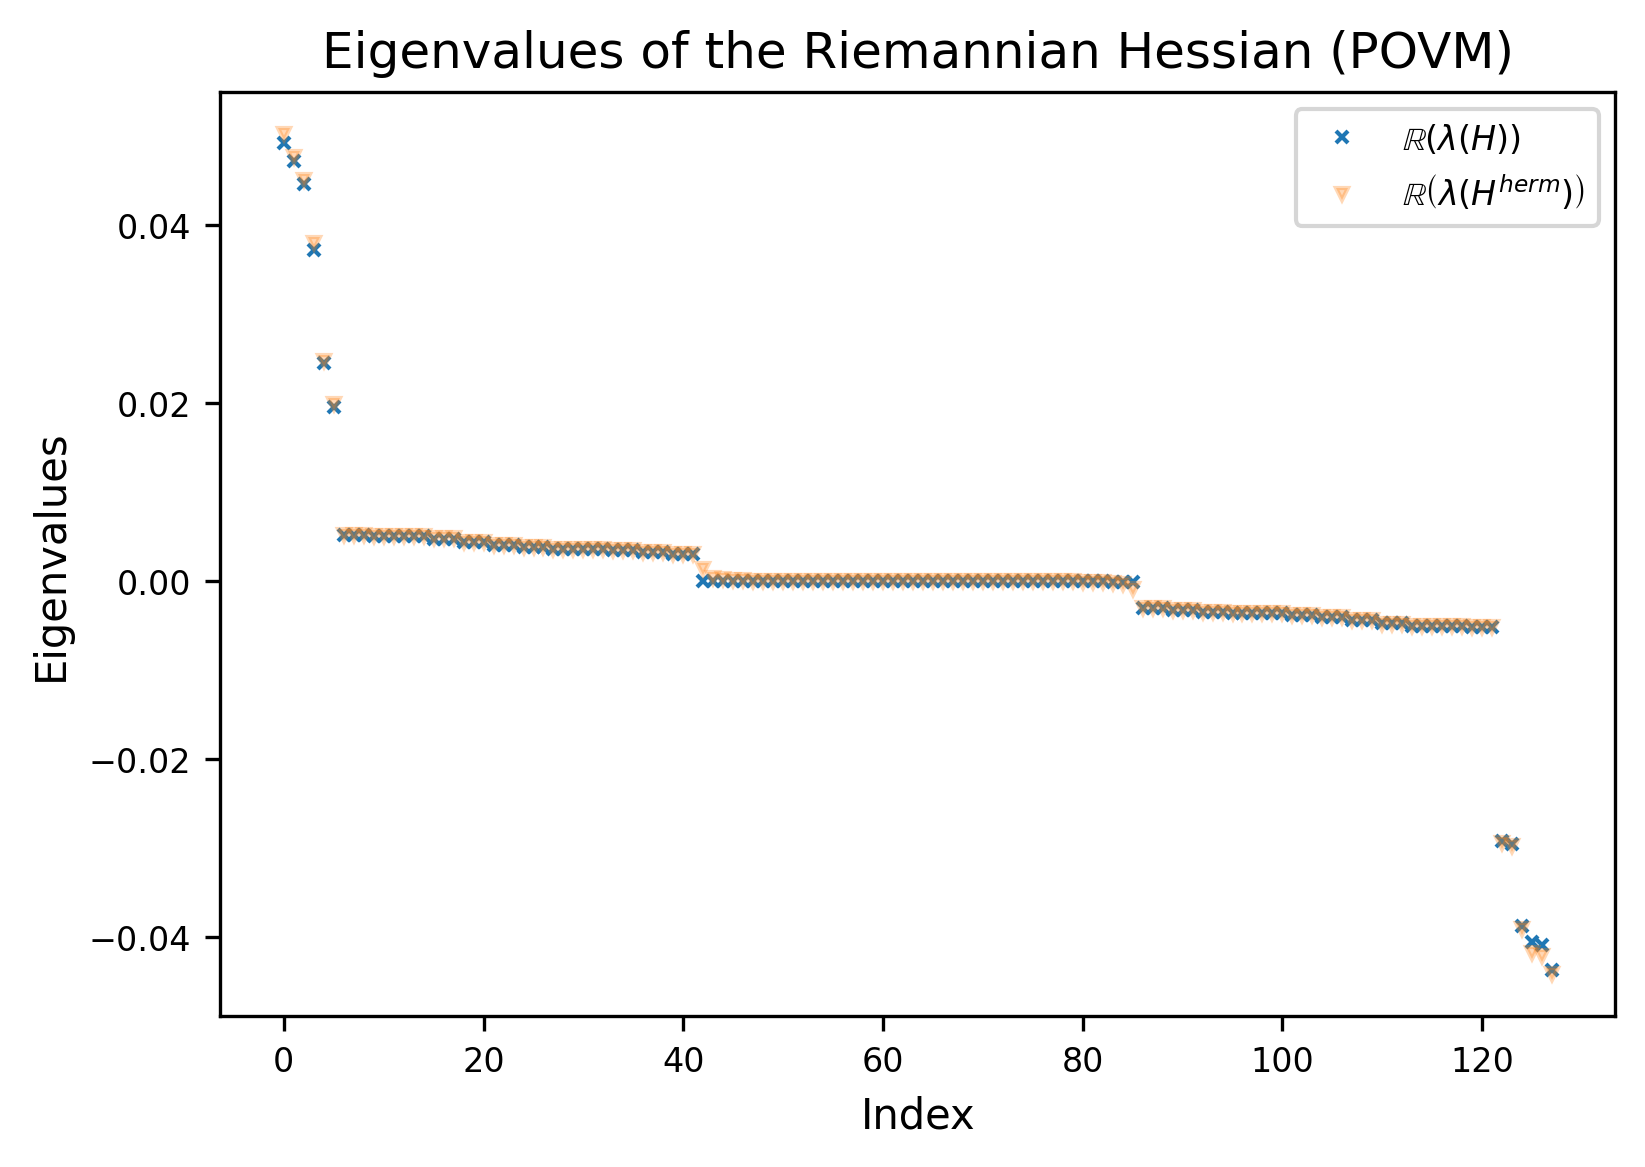

In [28]:
# get the eigenvalues of the hessian
plt.figure(figsize=(6, 4), dpi=300)
plt.title("Eigenvalues of the Riemannian Hessian (POVM)", fontsize=12)
plt.plot(eigvals_real, "x", markersize=3, label=r"$\mathbb{R}\left( \lambda(H) \right)$")
plt.plot(eigvals_hermitian_real, "v", markersize=3, label=r"$\mathbb{R}\left( \lambda(H^{herm}) \right)$", alpha=0.3)
plt.ylabel("Eigenvalues", fontsize=10)
plt.xlabel("Index", fontsize=10)
plt.legend()

2025-12-11 16:34:27,378 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-11 16:34:27,382 - matplotlib.mathtext - INFO - Substituting symbol I from STIXNonUnicode
2025-12-11 16:34:27,383 - matplotlib.mathtext - INFO - Substituting symbol m from STIXNonUnicode
2025-12-11 16:34:27,387 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-11 16:34:27,391 - matplotlib.mathtext - INFO - Substituting symbol I from STIXNonUnicode
2025-12-11 16:34:27,391 - matplotlib.mathtext - INFO - Substituting symbol m from STIXNonUnicode
2025-12-11 16:34:27,429 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-11 16:34:27,432 - matplotlib.mathtext - INFO - Substituting symbol I from STIXNonUnicode
2025-12-11 16:34:27,432 - matplotlib.mathtext - INFO - Substituting symbol m from STIXNonUnicode
2025-12-11 16:34:27,435 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-11 16:34:27,439 - matplotlib.matht

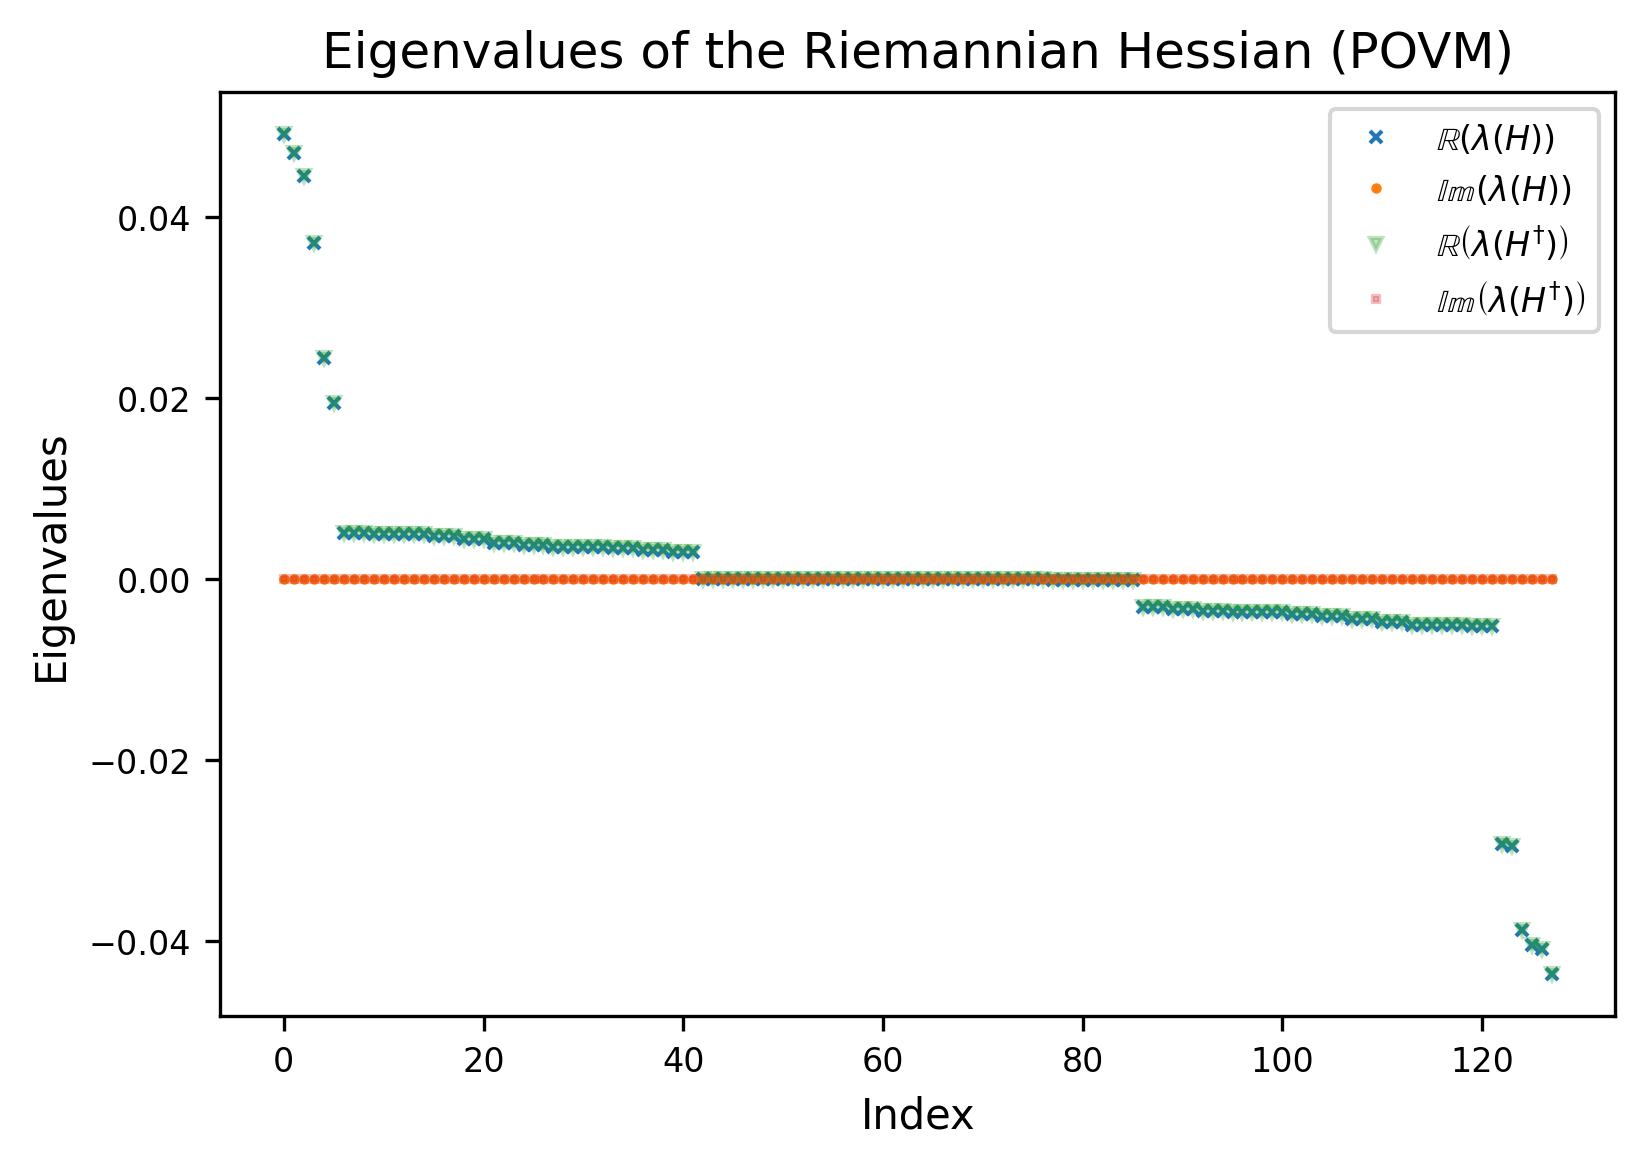

In [29]:
# get the eigenvalues of the hessian
plt.figure(figsize=(6, 4), dpi=300)
plt.title("Eigenvalues of the Riemannian Hessian (POVM)", fontsize=12)
plt.plot(eigvals_real, "x", markersize=3, label=r"$\mathbb{R}\left( \lambda(H) \right)$")
plt.plot(eigvals_imag, "o", markersize=1.5, label=r"$\mathbb{Im}\left( \lambda(H) \right)$")
plt.plot(eigvals_adjoint_real, "v", markersize=3, label=r"$\mathbb{R}\left( \lambda(H^{\dagger}) \right)$", alpha=0.3)
plt.plot(eigvals_adjoint_imag, "s", markersize=1.5, label=r"$\mathbb{Im}\left( \lambda(H^{\dagger}) \right)$", alpha=0.3)
plt.ylabel("Eigenvalues", fontsize=10)
plt.xlabel("Index", fontsize=10)
plt.legend()

2025-11-20 17:05:00,267 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-11-20 17:05:00,272 - matplotlib.mathtext - INFO - Substituting symbol I from STIXNonUnicode
2025-11-20 17:05:00,272 - matplotlib.mathtext - INFO - Substituting symbol m from STIXNonUnicode
2025-11-20 17:05:00,276 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-11-20 17:05:00,279 - matplotlib.mathtext - INFO - Substituting symbol I from STIXNonUnicode
2025-11-20 17:05:00,280 - matplotlib.mathtext - INFO - Substituting symbol m from STIXNonUnicode
2025-11-20 17:05:00,317 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-11-20 17:05:00,320 - matplotlib.mathtext - INFO - Substituting symbol I from STIXNonUnicode
2025-11-20 17:05:00,321 - matplotlib.mathtext - INFO - Substituting symbol m from STIXNonUnicode
2025-11-20 17:05:00,324 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-11-20 17:05:00,327 - matplotlib.matht

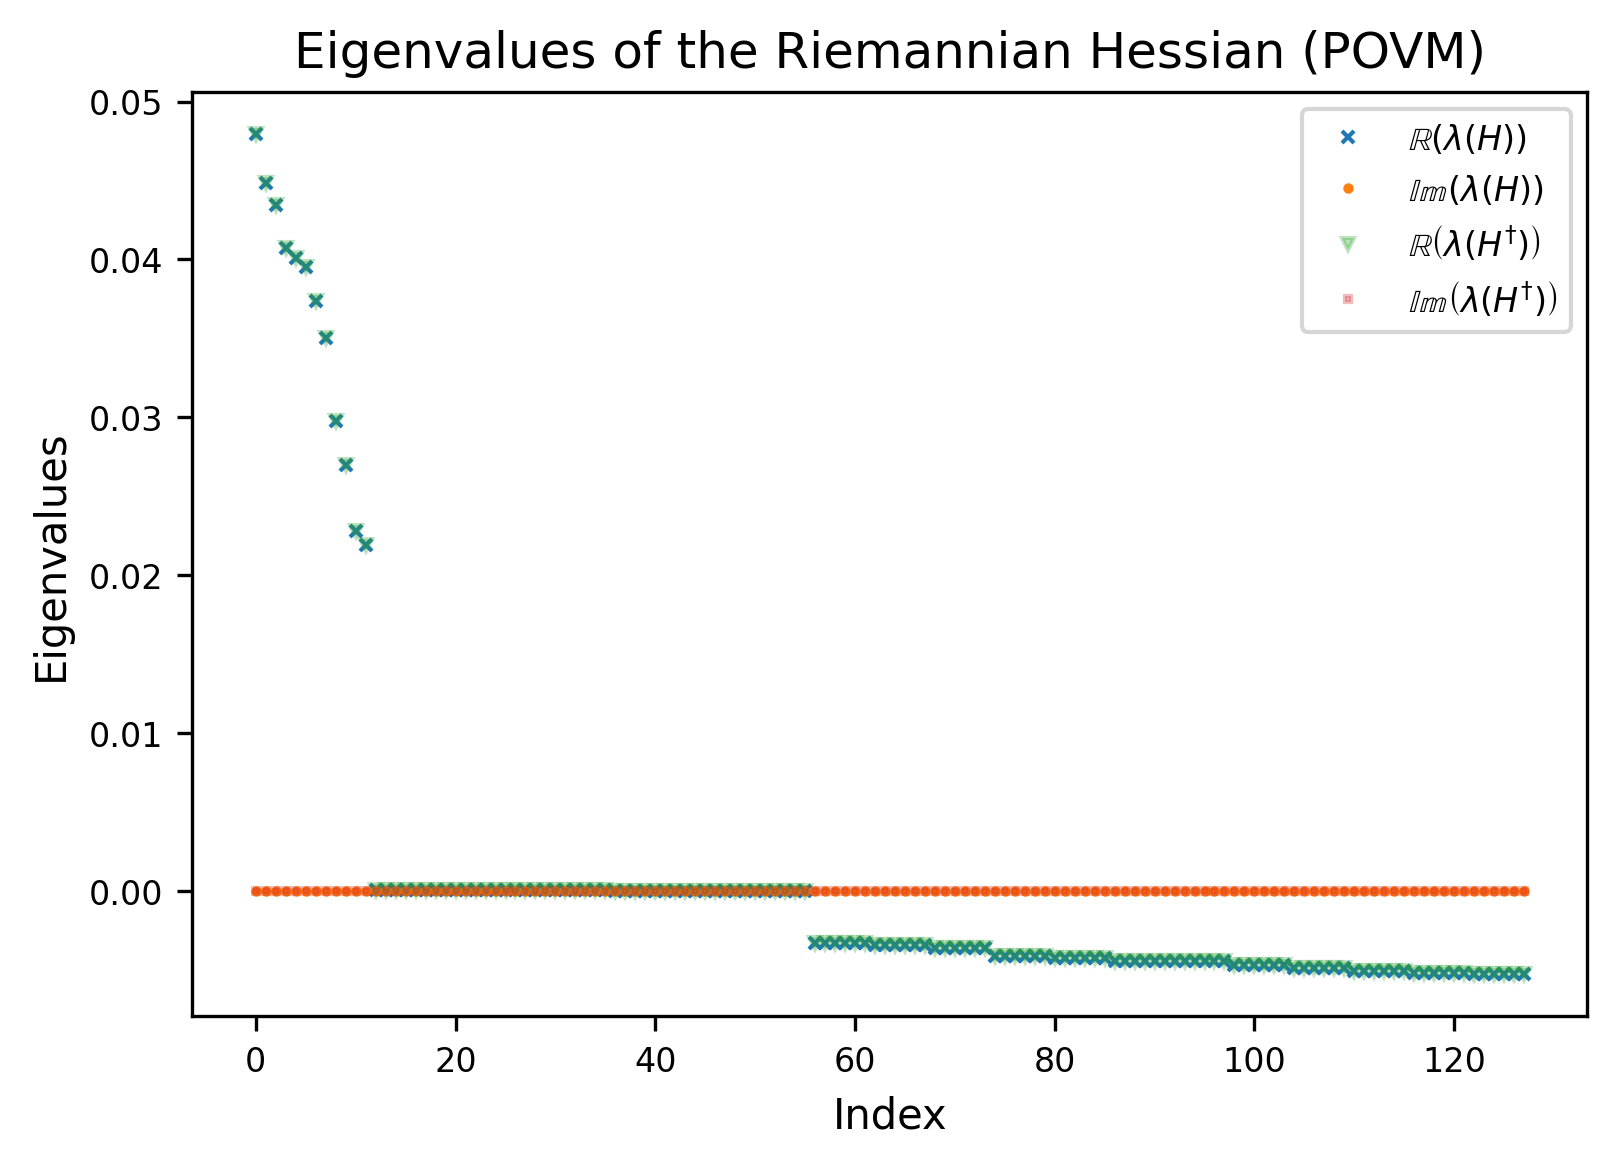

In [65]:
# get the eigenvalues of the hessian
plt.figure(figsize=(6, 4), dpi=300)
plt.title("Eigenvalues of the Riemannian Hessian (POVM)", fontsize=12)
plt.plot(eigvals_real, "x", markersize=3, label=r"$\mathbb{R}\left( \lambda(H) \right)$")
plt.plot(eigvals_imag, "o", markersize=1.5, label=r"$\mathbb{Im}\left( \lambda(H) \right)$")
plt.plot(eigvals_adjoint_real, "v", markersize=3, label=r"$\mathbb{R}\left( \lambda(H^{\dagger}) \right)$", alpha=0.3)
plt.plot(eigvals_adjoint_imag, "s", markersize=1.5, label=r"$\mathbb{Im}\left( \lambda(H^{\dagger}) \right)$", alpha=0.3)
plt.ylabel("Eigenvalues", fontsize=10)
plt.xlabel("Index", fontsize=10)
plt.legend()

## Further tests

In [106]:
# So the eigenvalues are the same but how would the eigenvectors look like?
eigenvals, eigenvects = jnp.linalg.eig(rhessian_matrix)
# test orthogonality of eigenvectors
eigenvects[:,4].conj().T @ eigenvects[:, 100]

Array(-3.72970452e-18+3.93918607e-17j, dtype=complex128)

In [ ]:
print(jnp.linalg.cond(rhessian_matrix))

jnp.linalg.norm(eigenvects @ eigenvects.conj().T - jnp.eye(eigenvects.shape[0]))

1.9298057418795313e+18


Array(8.11395526, dtype=float64)

In [94]:
(eigenvects @ eigenvects.conj().T)[1, 0]

Array(0.09606166-0.04362011j, dtype=complex128)

In [ ]:
rhessian_kraus_mgst = rhessian_matrix
Hh = rhessian_kraus_mgst.conj().T

# absolute and relative Hermiticity error
norm_diff = jnp.linalg.norm(rhessian_kraus_mgst - Hh)
norm_H = jnp.linalg.norm(rhessian_kraus_mgst)
print("||H - H^†||_F =", norm_diff)
print("relative ||H - H^†|| / ||H|| =", norm_diff / norm_H)

# check normality (A A^† == A^† A ?)
comm = rhessian_kraus_mgst @ Hh - Hh @ rhessian_kraus_mgst
print("||[H, H^†]||_F (zero => normal):", jnp.linalg.norm(comm))
print("is normal (allclose)?", jnp.allclose(rhessian_kraus_mgst @ Hh, Hh @ rhessian_kraus_mgst))

# Hermitian and anti-Hermitian parts
H_sym = 0.5 * (rhessian_kraus_mgst + Hh)   # Hermitian part
H_asym = 0.5 * (rhessian_kraus_mgst - Hh)  # anti-Hermitian part
print("||Hermitian part||, ||anti-Hermitian part||:",
      jnp.linalg.norm(H_sym), jnp.linalg.norm(H_asym))

# optionally inspect eigenvectors (right eigenvectors)
eigvals, eigvecs = jnp.linalg.eig(rhessian_kraus_mgst)
eigvals_h, eigvecs_h = jnp.linalg.eig(Hh)
# You can compare eigenvectors corresponding to matched eigenvalues after sorting/matching.


||H - H^†||_F = 0.03263829087273501
relative ||H - H^†|| / ||H|| = 0.2418294956480749
||[H, H^†]||_F (zero => normal): 0.0014312822077706272
is normal (allclose)? False
||Hermitian part||, ||anti-Hermitian part||: 0.13397381584667079 0.016319145436367505


In [ ]:
H_herm = 0.5 * (rhessian_kraus_mgst + rhessian_kraus_mgst.conj().T)
eigvals_hermitian = jnp.linalg.eigvals(H_herm)
jnp.linalg.norm(jnp.sort(eigvals_hermitian.real) - jnp.sort(eigvals.real)) / jnp.linalg.norm(eigenvals.real)

Array(0.01589143, dtype=float64)

# Euclidean vs Riemannian Hessian convergence against `num_sequences`

Metric for convergence? Condition number?

In [53]:
# Step 1: Compute the Euclidean Hessian and its spectrum
ehessian_tensor = riemannian_hessian_povm(
    K=kraus_tensor_mgst,
    A=povm_psd_mgst,
    B=state_psd_mgst,
    y=prob_matrix,
    J=indices_list,
    euclidean=True,
    return_gradient=False,
    hermitian_order=True,
)
ehessian_matrix = ehessian_tensor.reshape(2 * n * p, 2 * n * p)

# is this the hermitian matrix we expect?
ehessian_matrix_adjoint = ehessian_matrix.conj().T
print(jnp.allclose(ehessian_matrix, ehessian_matrix_adjoint))

True


In [52]:
ehessian_tensor_nonherm = riemannian_hessian_povm(
    K=kraus_tensor_mgst,
    A=povm_psd_mgst,
    B=state_psd_mgst,
    y=prob_matrix,
    J=indices_list,
    euclidean=True,
    return_gradient=False,
    hermitian_order=False
)
ehessian_matrix_nonherm = ehessian_tensor_nonherm.reshape(2 * n * p, 2 * n * p)

# is this the hermitian matrix we expect?
ehessian_matrix_adjoint_nonherm = ehessian_matrix_nonherm.conj().T
print(jnp.allclose(ehessian_matrix_nonherm, ehessian_matrix_adjoint_nonherm))

False


# Spectrum calculation

In [35]:
eeigvals = jnp.linalg.eigvals(ehessian_matrix)
eeigvals_real = eeigvals.real
eeigvals_real_ordered = jnp.sort(eeigvals_real, descending=True)

eeigvals_imag = eeigvals.imag
jnp.linalg.norm(eeigvals_imag), jnp.linalg.norm(eeigvals_real)

(Array(9.80613256e-18, dtype=float64), Array(0.24753905, dtype=float64))

In [45]:
eeigvals_nonherm = jnp.linalg.eigvals(ehessian_matrix_nonherm)
eeigvals_real_nonherm = eeigvals_nonherm.real
eeigvals_real_ordered_nonherm = jnp.sort(eeigvals_real_nonherm, descending=True)

eeigvals_imag_nonherm = eeigvals_nonherm.imag
jnp.linalg.norm(eeigvals_imag_nonherm), jnp.linalg.norm(eeigvals_real_nonherm)

(Array(1.69899223e-17, dtype=float64), Array(0.24535512, dtype=float64))

2025-12-12 14:33:56,688 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-12 14:33:56,694 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-12 14:33:56,699 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-12 14:33:56,758 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-12 14:33:56,765 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-12 14:33:56,769 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral


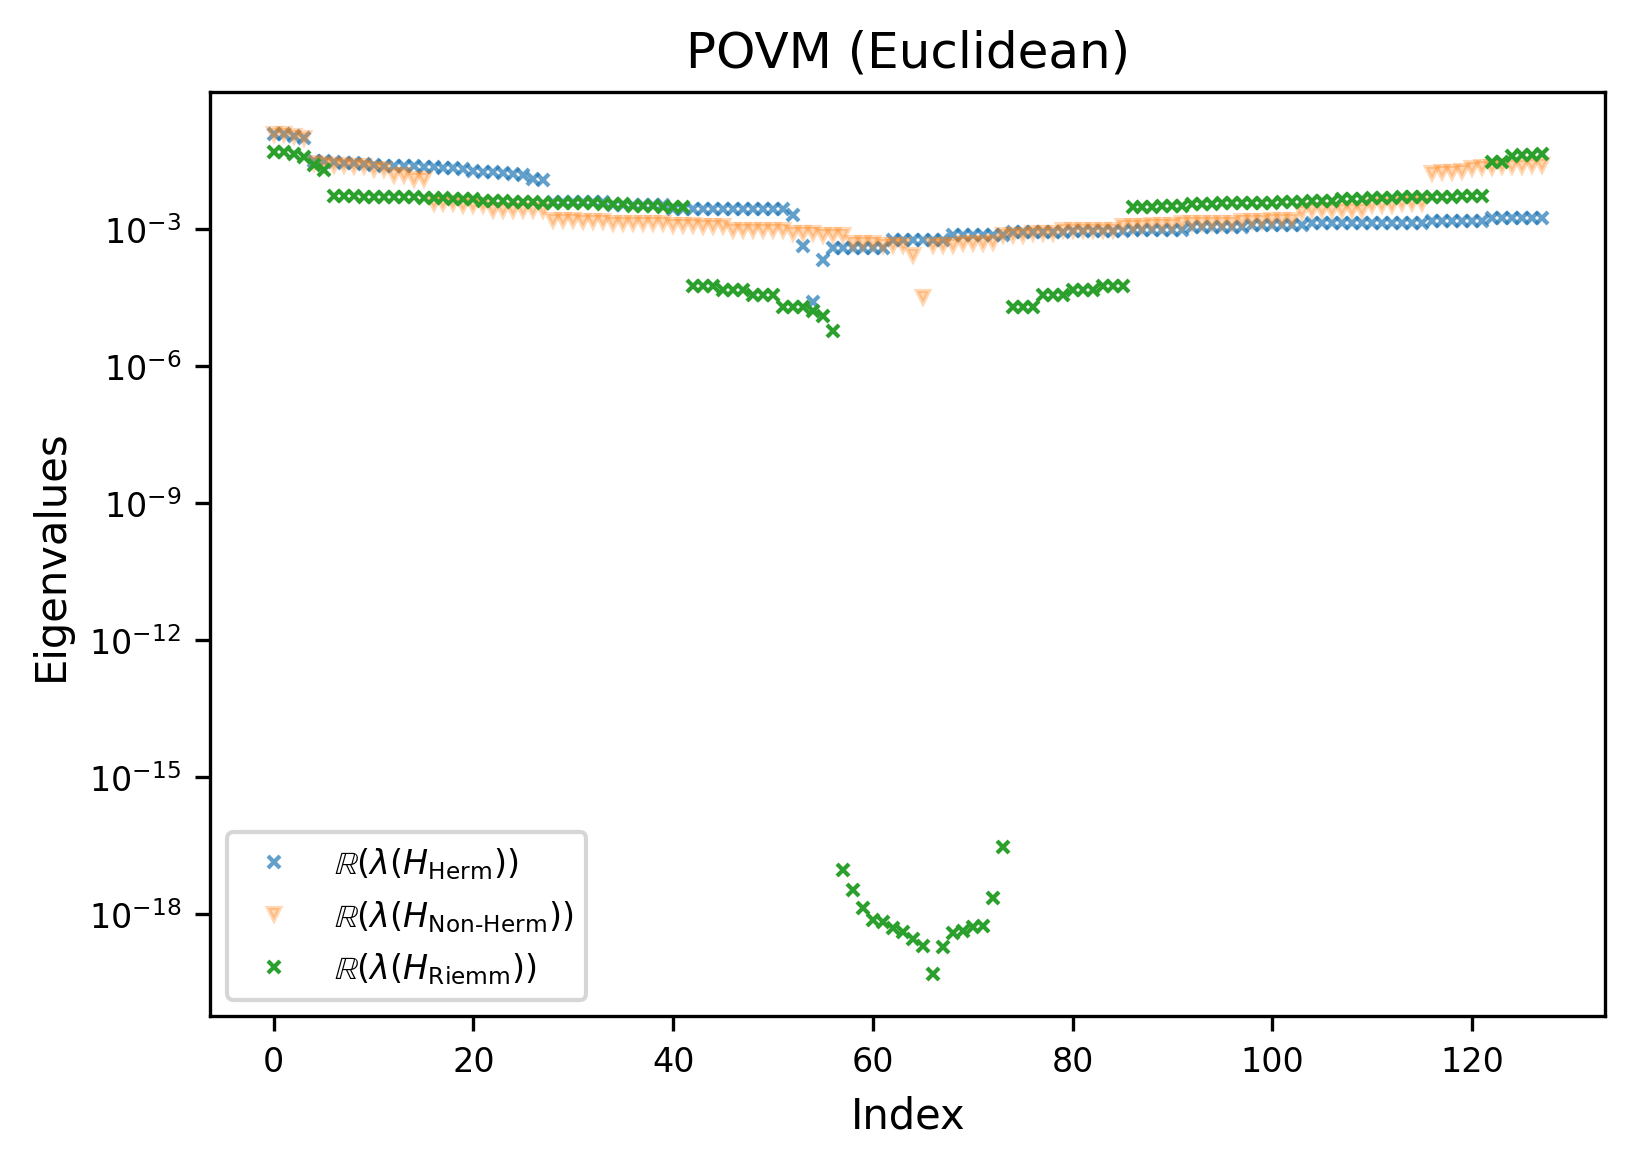

In [75]:
# get the eigenvalues of the hessian
plt.figure(figsize=(6, 4), dpi=300)
plt.title("POVM (Euclidean)", fontsize=12)
plt.semilogy(jnp.abs(eeigvals_real_ordered), "x", markersize=3, label=r"$\mathbb{R}\left( \lambda(H_{\text{Herm}}) \right)$", alpha=0.7)
plt.semilogy(jnp.abs(eeigvals_real_ordered_nonherm), "v", markersize=3, label=r"$\mathbb{R}\left( \lambda(H_{\text{Non-Herm}}) \right)$", alpha=0.3)
plt.plot(jnp.abs(eigvals_real), "x", markersize=3, label=r"$\mathbb{R}\left( \lambda(H_{\text{Riemm}}) \right)$")
plt.ylabel("Eigenvalues", fontsize=10)
plt.xlabel("Index", fontsize=10)
plt.legend()

In [58]:
jnp.linalg.matrix_rank(ehessian_matrix)

Array(128, dtype=int64)

In [59]:
jnp.linalg.matrix_rank(ehessian_matrix_nonherm)

Array(128, dtype=int64)

In [73]:
jnp.linalg.matrix_rank(rhessian_matrix)

Array(111, dtype=int64)

# Checking Kraus spectrum

In [83]:
from mGST.utility_functions_comparisons import compute_euclidean_hessian_kraus

In [88]:
type(kraus_tensor_mgst), type(povm_mgst), type(state_mgst), type(prob_matrix), type(indices_list)

(numpy.ndarray,
 jaxlib.xla_extension.ArrayImpl,
 jaxlib.xla_extension.ArrayImpl,
 numpy.ndarray,
 list)

In [91]:
ehessian_mtrx_kraus = compute_euclidean_hessian_kraus(
    kraus_tensor=kraus_tensor_mgst, povm_mgst=povm_mgst, state_mgst=state_mgst, indices_list=indices_list, prob_matrix=prob_matrix
)

In [93]:
# check if they are hermitian
ehessian_mtrx_kraus_adjoint = ehessian_mtrx_kraus.conj().T
jnp.allclose(ehessian_mtrx_kraus, ehessian_mtrx_kraus_adjoint)

Array(True, dtype=bool)

In [100]:
# create hessian with different ordering.
ehessian_mtrx_kraus_herm_order = ehessian_mtrx_kraus.copy()
n_kraus = kraus_tensor_mgst.size

Hxx = ehessian_mtrx_kraus_herm_order[:n_kraus, :n_kraus]
Hxconjx = ehessian_mtrx_kraus_herm_order[:n_kraus, n_kraus:]

# H00
ehessian_mtrx_kraus_herm_order[:n_kraus, :n_kraus] = Hxconjx
# H01
ehessian_mtrx_kraus_herm_order[:n_kraus, n_kraus:] = Hxx
# H11
ehessian_mtrx_kraus_herm_order[n_kraus:, n_kraus:] = Hxconjx.conj()
# H10
ehessian_mtrx_kraus_herm_order[n_kraus:, :n_kraus] = Hxx.conj()

# Check if this new ordering is hermitian
ehessian_mtrx_kraus_herm_order_adjoint = ehessian_mtrx_kraus_herm_order.conj().T
jnp.allclose(ehessian_mtrx_kraus_herm_order, ehessian_mtrx_kraus_herm_order_adjoint)


Array(False, dtype=bool)

In [104]:
# Compute the eigenvalues
eigvals_kraus_og_order = jnp.linalg.eigvals(ehessian_mtrx_kraus)
eigvals_kraus_herm_order = jnp.linalg.eigvals(ehessian_mtrx_kraus_herm_order)
eigvals_kraus_og_order_real = eigvals_kraus_og_order.real
eigvals_kraus_herm_order_real = eigvals_kraus_herm_order.real
eigvals_kraus_og_order_imag = eigvals_kraus_og_order.imag
eigvals_kraus_herm_order_imag = eigvals_kraus_herm_order.imag

In [105]:
# are both imaginary parts close to zero?
jnp.linalg.norm(eigvals_kraus_og_order_imag), jnp.linalg.norm(eigvals_kraus_herm_order_imag)

(Array(2.76240155e-16, dtype=float64), Array(5.3002789e-12, dtype=float64))

2025-12-15 12:04:13,227 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-15 12:04:13,232 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-15 12:04:13,289 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-15 12:04:13,294 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral


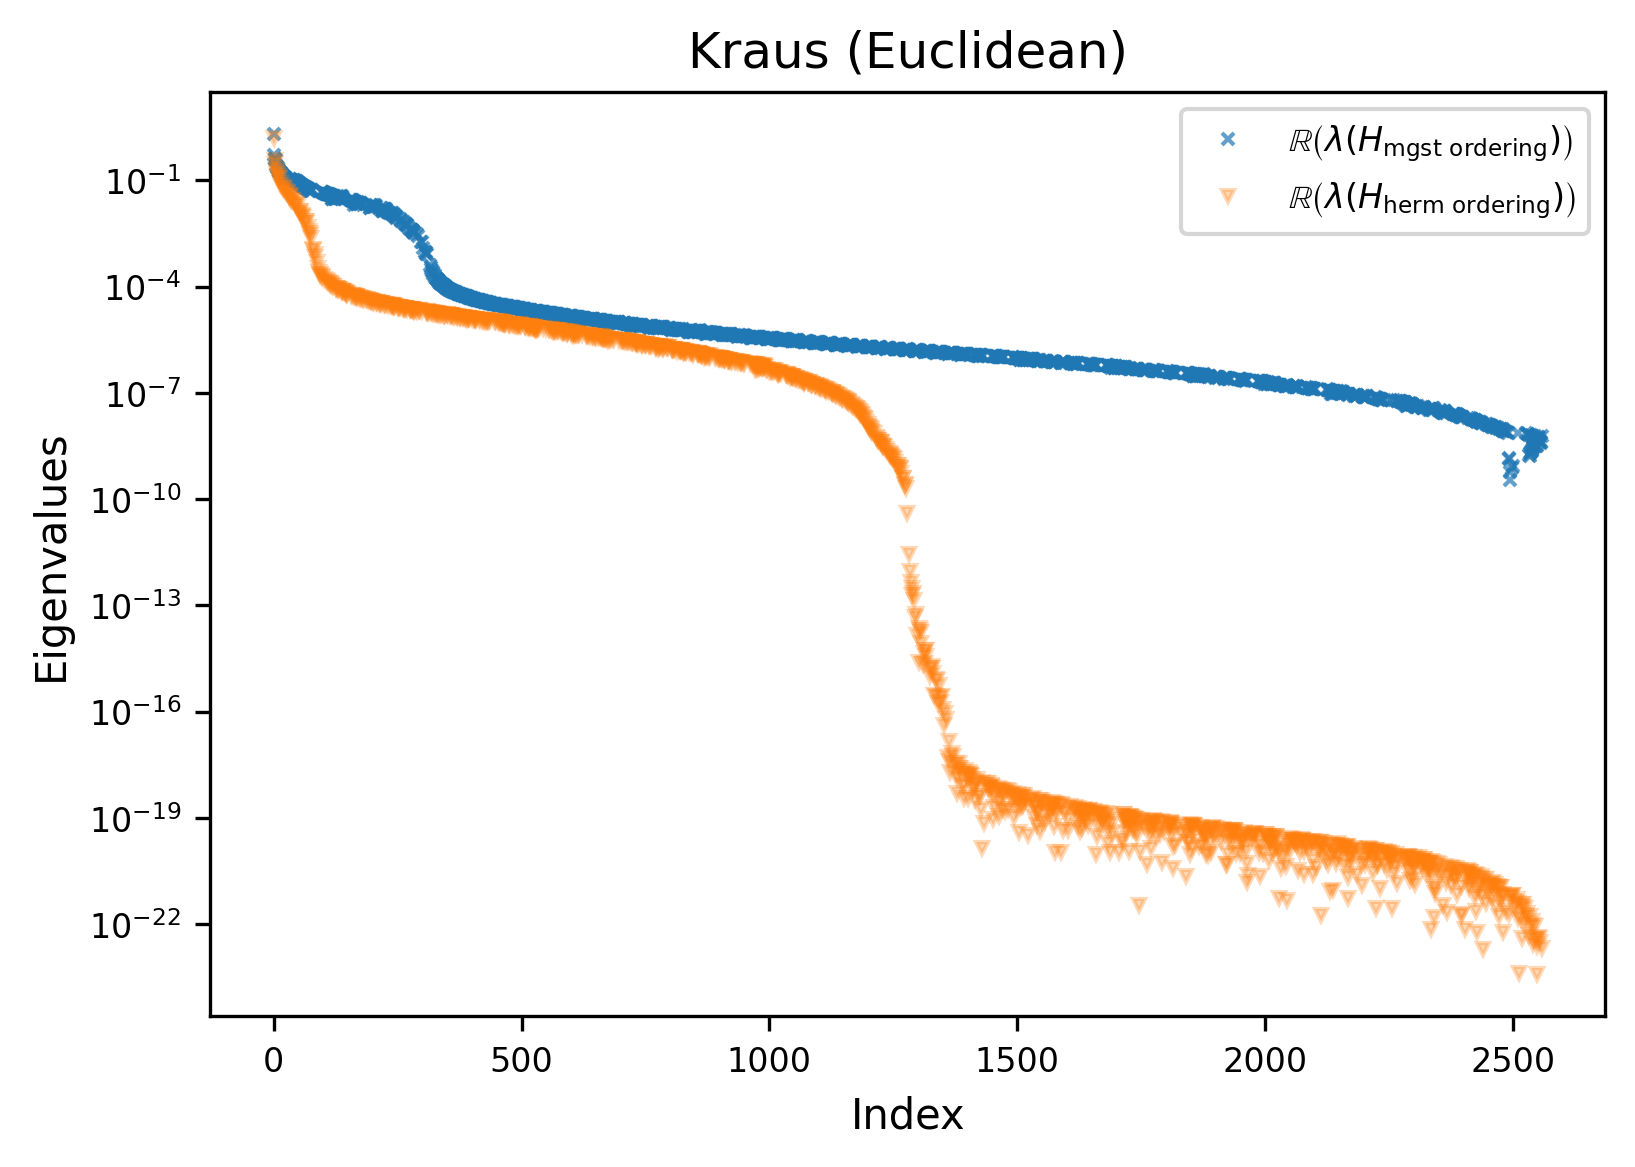

In [111]:
# get the eigenvalues of the hessian
plt.figure(figsize=(6, 4), dpi=300)
plt.title("Kraus (Euclidean)", fontsize=12)
plt.semilogy(eigvals_kraus_og_order_real, "x", markersize=3, label=r"$\mathbb{R}\left( \lambda(H_{\text{mgst ordering}}) \right)$", alpha=0.7)
plt.semilogy(eigvals_kraus_herm_order_real, "v", markersize=3, label=r"$\mathbb{R}\left( \lambda(H_{\text{herm ordering}}) \right)$", alpha=0.3)
plt.ylabel("Eigenvalues", fontsize=10)
plt.xlabel("Index", fontsize=10)
plt.legend()

In [109]:
jnp.linalg.matrix_rank(ehessian_mtrx_kraus)

Array(2560, dtype=int64)

In [122]:
from mGST.utility_functions_comparisons import compute_euclidean_derivatives_kraus
from mGST.additional_fns import transp

In [116]:
derivatives_kraus = compute_euclidean_derivatives_kraus(
    kraus_tensor=kraus_tensor_mgst,
    povm_mgst=povm_mgst,
    state_mgst=state_mgst,
    indices_list=indices_list,
    prob_matrix=prob_matrix,
)

In [117]:
derivatives_kraus.keys()

dict_keys(['dK_', 'dM10', 'dM11', 'dd', 'dconjd'])

In [118]:
dM11 = derivatives_kraus['dM11']
dM10 = derivatives_kraus['dM10']
dd = derivatives_kraus['dd']
dconjd = derivatives_kraus['dconjd']
dK_ = derivatives_kraus['dK_']

In [120]:
# Is this a critical point?
jnp.linalg.norm(dK_)/jnp.linalg.norm(kraus_tensor_mgst)

Array(0.00566938, dtype=float64)

In [126]:
# Second derivatives
num_gates, kraus_rank, dim, dim =  kraus_tensor_mgst.shape
dim_sqrd = int(dim**2)
n = kraus_rank * dim
vect_dim = n * dim
K = kraus_tensor_mgst

Fyconjy = dM11.reshape(num_gates, vect_dim, num_gates, vect_dim) + np.einsum("ijklmnop->ikmojlnp", dconjd).reshape((num_gates, vect_dim, num_gates, vect_dim))
Fyy = dM10.reshape(num_gates, vect_dim, num_gates, vect_dim) + np.einsum("ijklmnop->ikmojlnp", dd).reshape((num_gates, vect_dim, num_gates, vect_dim))

In [137]:
fixed_gates = []
rhessian_kraus_mgst = np.zeros((2, num_gates, vect_dim, 2, num_gates, vect_dim)).astype(np.complex128)
G = np.zeros((2, num_gates, vect_dim)).astype(np.complex128)
X = np.einsum("ijkl,ijnm -> iknlm", K, K.conj()).reshape((num_gates, dim_sqrd, dim_sqrd))

for k in range(num_gates):
   # Reshaping into isometry
    Fy = dK_[k].reshape((n, dim))
    Y = K[k].reshape((n, dim))
    # riemannian gradient under canonical metric
    rGrad = Fy.conj() - Y @ Fy.T @ Y

    # saving rgrad for gate k as a vector
    G[0, k, :] = rGrad.reshape(-1)
    # saving (rgrad)* for gate k as a vector
    G[1, k, :] = rGrad.conj().reshape(-1)

    # projector onto orthogonal complement of stiefel manifold. I = X X^dag + X_perp X_perp^dag
    P = np.eye(n) - Y @ Y.T.conj()
    # transpose superoperator
    T = transp(n, dim)
    # Hessian assembly
    # See theorem 1, equation A27
    # This is already the riemannian hessian elements
    H00 = (
        -(np.kron(Y, Y.T)) @ T @ Fyy[k, :, k, :].T
        + Fyconjy[k, :, k, :].T.conj()
        - (np.kron(np.eye(n), Y.T @ Fy)) / 2
        - (np.kron(Y @ Fy.T, np.eye(dim))) / 2
        - (np.kron(P, Fy.T.conj() @ Y.conj())) / 2
    )
    H01 = (
        Fyy[k, :, k, :].T.conj()
        - np.kron(Y, Y.T) @ T @ Fyconjy[k, :, k, :].T
        + (np.kron(Fy.conj(), Y.T) @ T) / 2
        + (np.kron(Y, Fy.T.conj()) @ T) / 2
    )

    # Full hessian on Z and Z*
    # See relation in equation A37 of individual hessian submatrices
    # Riemannian Hessian with correction terms
    rhessian_kraus_mgst[0, k, :, 0, k, :] = H00
    rhessian_kraus_mgst[0, k, :, 1, k, :] = H01 
    rhessian_kraus_mgst[1, k, :, 0, k, :] = H01.conj()
    rhessian_kraus_mgst[1, k, :, 1, k, :] = H00.conj()

In [141]:
rhessian_kraus_mgst_mtrx = rhessian_kraus_mgst.reshape(2 * num_gates * vect_dim, 2 * num_gates * vect_dim)

In [142]:
# is the riemannian hessian hermitian?
rhessian_kraus_mgst_mtrx_adjoint = rhessian_kraus_mgst_mtrx.conj().T
jnp.allclose(rhessian_kraus_mgst_mtrx, rhessian_kraus_mgst_mtrx_adjoint)

Array(False, dtype=bool)

In [144]:
reigvals_kraus =jnp.linalg.eigvals(rhessian_kraus_mgst_mtrx)
reigvals_kraus_real = reigvals_kraus.real
reigvals_kraus_imag = reigvals_kraus.imag
jnp.linalg.norm(reigvals_kraus_imag), jnp.linalg.norm(reigvals_kraus_real)

(Array(1.48343191e-16, dtype=float64), Array(0.80700825, dtype=float64))

In [173]:
# reigvals_kraus_real_ordered = jnp.sort(reigvals_kraus_real, descending=True)
# eigvals_kraus_og_order_real_ordered = jnp.sort(eigvals_kraus_og_order_real, descending=True)

reigvals_kraus_real_ordered = jnp.sort(jnp.abs(reigvals_kraus_real), descending=True)
eigvals_kraus_og_order_real_ordered = jnp.sort(jnp.abs(eigvals_kraus_og_order_real), descending=True)

In [171]:
eigvals_kraus_og_order_real_ordered.min(), reigvals_kraus_real_ordered.min()

(Array(-0.04829247, dtype=float64), Array(-0.05655572, dtype=float64))

2025-12-15 16:58:47,596 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-15 16:58:47,602 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-15 16:58:47,668 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2025-12-15 16:58:47,677 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral


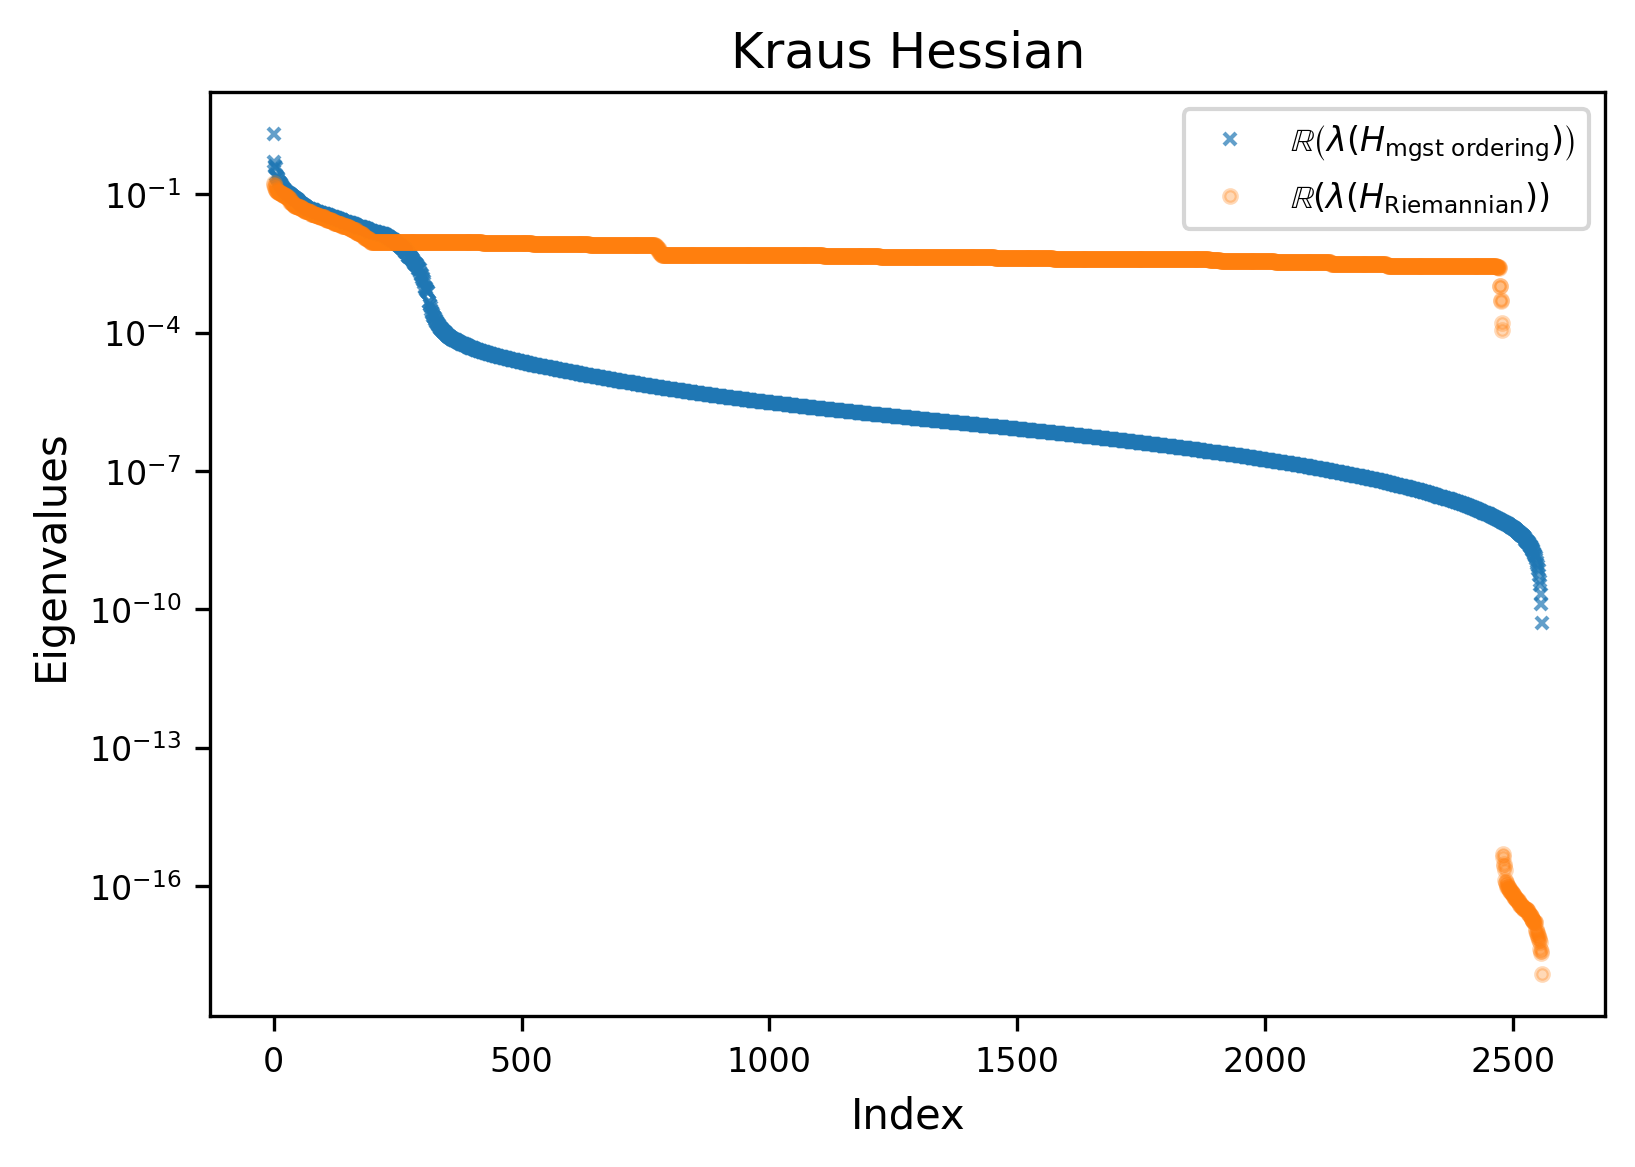

In [174]:
# get the eigenvalues of the hessian
plt.figure(figsize=(6, 4), dpi=300)
plt.title("Kraus Hessian", fontsize=12)
plt.semilogy(eigvals_kraus_og_order_real_ordered, "x", markersize=3, label=r"$\mathbb{R}\left( \lambda(H_{\text{mgst ordering}}) \right)$", alpha=0.7)
# plt.semilogy(jnp.abs(eigvals_kraus_herm_order_real), "v", markersize=3, label=r"$\mathbb{R}\left( \lambda(H_{\text{herm ordering}}) \right)$", alpha=0.3)
plt.plot(reigvals_kraus_real_ordered, "o", markersize=3, label=r"$\mathbb{R}\left( \lambda(H_{\text{Riemannian}}) \right)$", alpha=0.3)
plt.ylabel("Eigenvalues", fontsize=10)
plt.xlabel("Index", fontsize=10)
plt.legend()

In [155]:
jnp.linalg.matrix_rank(rhessian_kraus_mgst_mtrx)

Array(2480, dtype=int64)

In [159]:
rhessian_kraus_mgst_mtrx.shape

(2560, 2560)

In [156]:
jnp.linalg.matrix_rank(ehessian_mtrx_kraus_herm_order)

Array(1280, dtype=int64)

In [ ]:
# gauge degrees of freedom here:
dof_kraus = 2560 - 2480
print("dof_kraus:", dof_kraus)

80

In [206]:
# for all kraus tensors I would need this many iterations:
def stiefel_dof_kraus(dim:int, kraus_rank:int, num_gates:int) -> int:
    n, p = kraus_rank * dim, dim
    dof_per_gate = 2 * n * p - p**2
    return dof_per_gate * num_gates

kraus_rank_2q = 16
dim_2q = 2**2
num_gates_2q = 5
dof_2q = stiefel_dof_kraus(dim_2q, kraus_rank_2q, num_gates_2q)

kraus_rank_4q = 4
dim_4q = 2**4
num_gates_4q = 9
dof_4q = stiefel_dof_kraus(dim_4q, kraus_rank_4q, num_gates_4q)

print("DOF 2Q:", dof_2q)
print("DOF 4Q:", dof_4q)

DOF 2Q: 2480
DOF 4Q: 16128


In [207]:
time_hvp_2q = 57.5e-3 # rank 16, 5 gates, 800 gate sequences
time_hvp_4q = 3.99 # rank 4, 9 gates, 2,000 gate sequences
print(f"Time for 2Q Hessian approx: {time_hvp_2q * dof_2q} s")
print(f"Time for 4Q Hessian approx: {time_hvp_4q * dof_4q/3600} h")

Time for 2Q Hessian approx: 142.6 s
Time for 4Q Hessian approx: 17.8752 h


# Conclusions
1. Constructing the Hessian by iterating over all parameters seems complicated. Already with kraus rank 1 and `num_sequences=2000` it would take around 2.5 hours!
2. How many iterations would we need with the spectral density aproach?
    * It seems like an approach is turn the hessian into "G-hermitian".
    *

# Finding the similar matrix that is hermitian

We focus on a single kraus operator for now

In [216]:
k = 0
rhessian_kraus_mgst_gate_k = rhessian_kraus_mgst[ :, k, :, :, k, :]
print(rhessian_kraus_mgst_gate_k.shape)

rhessian_kraus_mgst_gate_k_mtrx = rhessian_kraus_mgst_gate_k.reshape(2 * vect_dim, 2 * vect_dim)
print(rhessian_kraus_mgst_gate_k_mtrx.shape)

print("Is this hermitian?")
rhessian_kraus_mgst_gate_k_mtrx_adjoint = rhessian_kraus_mgst_gate_k_mtrx.conj().T
print(jnp.allclose(rhessian_kraus_mgst_gate_k_mtrx, rhessian_kraus_mgst_gate_k_mtrx_adjoint))

(2, 256, 2, 256)
(512, 512)
Is this hermitian?
False


In [ ]:
# Create the G matrix that changes to a similar matrix that is hermitian
